In [33]:
from langgraph.graph import StateGraph , START ,END
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from dotenv import load_dotenv
from typing import TypedDict
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [18]:
load_dotenv()

True

In [27]:
llm=HuggingFaceEndpoint(model='meta-llama/Llama-3.1-8B-Instruct',
                        task='text_generation')
model=ChatHuggingFace(llm=llm)

In [28]:
class LLMState(TypedDict):
    question:str
    answer:str
    

In [34]:
def llm_QnA(state:LLMState)->LLMState:
    # Extract Question
    question =state['question']

    parser=StrOutputParser()
    #creating prompt 
    template=PromptTemplate(template='Answer the following Question :{Question}',
                          input_variables=['Question'])
    
    prompt=template.invoke({'Question':question})
    
    response=model.invoke(prompt)

    result=parser.invoke(response)

    state['answer']=result

    return state
    

In [35]:
# Create graph 
graph=StateGraph(LLMState)

# create node 
graph.add_node('llm-QnA',llm_QnA)

# create edge
graph.add_edge(START, 'llm-QnA')
graph.add_edge('llm-QnA', END)

# compile graphb
workflow=graph.compile()


In [36]:
# Execute 
initial_state={'question': 'How far is venus from earth?'}
final_state=workflow.invoke(initial_state)

In [37]:
final_state

{'question': 'How far is venus from earth?',
 'answer': 'The average distance from Earth to Venus is approximately 25 million miles (40.2 million kilometers) or 108.2 million kilometers when at its farthest (aphelion). However, it can be as close as 25 million miles (40.2 million kilometers or 38.87 million kilometers) at its closest (perihelion). \n\nVenus and Earth are very close to each other in space and their orbital paths are known as a "proximity" or "proximity to Earth."'}

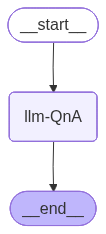

In [38]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())